# 85%-sequence-identity clustered dual split — peak design

Same procedure as `seqid70_cluster_split.ipynb` but with a **stricter 85% identity** threshold.
A higher threshold splits the big fluorescent-protein lineages into finer sub-families, so fewer
proteins get linked; a random split then leaks slightly less than at 70%, but still substantially,
because the dominant lineage (avGFP) stays tight even at 85% identity.

**What this notebook does** (no existing file, weight, or code is modified):
1. Cluster all curated sequences at **85% identity** (BLOSUM62 global alignment, identity =
   identical residues / shorter-sequence length; single-linkage / connected components).
2. Build a **cluster-aware coordinated dual split** keeping the pipeline structure — disjoint val
   sets and the invariants `S_test ⊆ O_train`, `O_test ⊆ S_train` — with every boundary between
   clusters.
3. Quantify leakage and visualize.

**Outputs (new files only):** `seqid85_clusters.csv`, `dual_splits_seqid85.csv`.
Consumed by `surrogate_oracle_peak_seqid85.ipynb`.


## 0. Setup + load curated sequences / peaks

In [1]:
import os, csv, json, time, numpy as np
try:
    import arcadia_pycolor as apc; apc.mpl.setup(); HAVE_APC=True
except Exception:
    HAVE_APC=False
import matplotlib.pyplot as plt
class _C:
    def __getattr__(self,k): return getattr(apc,k) if HAVE_APC else {"aegean":"#2b6c8f","amber":"#f6a200","rose":"#c5474b","seaweed":"#3b8a6e","gray":"#888888","wish":"#5088c5","aster":"#7a5ea8","lime":"#97cd3f","dragon":"#c85152"}.get(k,"#333333")
apc_c=_C()
CUR="../dataset_pipeline/data/peak/curated"
rows=list(csv.DictReader(open(os.path.join(CUR,"peaks_assignments.csv")))); N=len(rows)
names=[r["name"] for r in rows]
peaks=np.load(os.path.join(CUR,"peaks.npy")).astype(np.float32)
seqs=[None]*N; h=None
for line in open(os.path.join(CUR,"sequences.fasta")):
    line=line.strip()
    if line.startswith(">"): h=int(line[1:].split("|")[0])
    elif line: seqs[h]=line
assert all(s is not None for s in seqs)
L=np.array([len(s) for s in seqs])
print(f"N={N} curated proteins | seq len {L.min()}-{L.max()}")


N=758 curated proteins | seq len 134-582


## 1. Cluster at 85% sequence identity

Identical method to the 70% notebook — only `THR` changes to **0.85**. Pairwise BLOSUM62 global
alignment (gap −11/−1), identity = identical aligned residues / shorter-sequence length; proteins
linked at identity ≥ 0.85; clusters = connected components. A 5-mer containment prefilter (≥0.30)
skips pairs that cannot reach the threshold before aligning.

In [2]:
from Bio.Align import PairwiseAligner, substitution_matrices
aligner=PairwiseAligner()
aligner.substitution_matrix=substitution_matrices.load("BLOSUM62")
aligner.open_gap_score=-11; aligner.extend_gap_score=-1; aligner.mode="global"

THR=0.85           # identity threshold for an edge  (stricter than the 70% notebook)
K=5; PRE=0.30       # 5-mer containment prefilter (a lower bound; safe at higher THR)
kmers=[frozenset(s[i:i+K] for i in range(len(s)-K+1)) for s in seqs]

parent=list(range(N))
def find(x):
    while parent[x]!=x: parent[x]=parent[parent[x]]; x=parent[x]
    return x
def union(a,b):
    ra,rb=find(a),find(b)
    if ra!=rb: parent[ra]=rb

t0=time.time(); n_aln=0; n_edge=0
for i in range(N):
    ki=kmers[i]
    for j in range(i+1,N):
        mn=min(len(ki),len(kmers[j]))
        if mn==0 or len(ki & kmers[j])/mn < PRE: continue
        n_aln+=1
        al=aligner.align(seqs[i],seqs[j])[0]
        if al.counts().identities/min(L[i],L[j])>=THR:
            union(i,j); n_edge+=1
print(f"clustering done in {time.time()-t0:.0f}s | aligned {n_aln:,} pairs | {n_edge:,} edges >=85% identity")

comp={}
for i in range(N): comp.setdefault(find(i),[]).append(i)
comps=sorted(comp.values(), key=len, reverse=True)
clab=np.empty(N,dtype=int)
for cid,members in enumerate(comps):
    for i in members: clab[i]=cid
sizes=np.bincount(clab)
print(f"{len(comps)} clusters | largest {sizes.max()} ({100*sizes.max()/N:.0f}% of N) | "
      f"singletons {(sizes==1).sum()} | top10 sizes {sizes[:10].tolist()}")


clustering done in 20s | aligned 45,874 pairs | 36,528 edges >=85% identity
93 clusters | largest 254 (34% of N) | singletons 49 | top10 sizes [254, 99, 62, 37, 30, 20, 16, 16, 15, 12]


### 1a. Cluster-size distribution

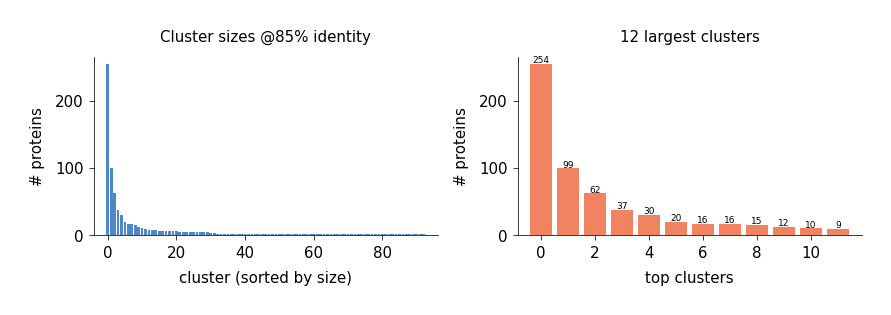

wrote ../dataset_pipeline/data/peak/curated/seqid85_clusters.csv


In [3]:
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].bar(np.arange(len(sizes)),sizes,color=apc_c.aegean)
ax[0].set_xlabel("cluster (sorted by size)"); ax[0].set_ylabel("# proteins"); ax[0].set_title("Cluster sizes @85% identity")
ax[1].bar(np.arange(min(12,len(sizes))),sizes[:12],color=apc_c.amber)
for i,v in enumerate(sizes[:12]): ax[1].text(i,v+2,str(v),ha="center",fontsize=9)
ax[1].set_xlabel("top clusters"); ax[1].set_ylabel("# proteins"); ax[1].set_title("12 largest clusters")
plt.tight_layout(); plt.show()
with open(os.path.join(CUR,"seqid85_clusters.csv"),"w",newline="") as fh:
    w=csv.writer(fh); w.writerow(["index","name","cluster_id","cluster_size"])
    for i in range(N): w.writerow([i,names[i],int(clab[i]),int(sizes[clab[i]])])
print("wrote",os.path.join(CUR,"seqid85_clusters.csv"))


## 2. Cluster-aware coordinated dual split

Same greedy whole-cluster allocator as the 70% notebook (deterministic; clusters sorted by
descending size, each placed in the carve-role with the largest remaining deficit if it fits within
a tolerance, else train). Surrogate carves ~15% test / ~15% val as whole clusters; oracle carves
its test/val as whole clusters from the surrogate-train pool only.

In [4]:
TOL=20
def alloc(pool, targets):
    pool=np.asarray(pool); cl=np.unique(clab[pool])
    csize={c:int((clab[pool]==c).sum()) for c in cl}
    deficit=dict(targets); role_of={}
    for cc in sorted(cl, key=lambda c:(-csize[c], c)):
        s=csize[cc]; best=None
        for r in targets:
            if deficit[r]>0 and s<=deficit[r]+TOL and (best is None or deficit[r]>deficit[best]):
                best=r
        if best is None: role_of[cc]="train"
        else: role_of[cc]=best; deficit[best]-=s
    role=np.array(["train"]*N,dtype=object)
    for cc in cl: role[pool[clab[pool]==cc]]=role_of[cc]
    return role

n_te=int(round(0.15*N)); n_va=int(round(0.15*N))
Srole=alloc(np.arange(N), {"test":n_te,"val":n_va})
s_train_pool=np.where(Srole=="train")[0]
Orole=np.array(["train"]*N,dtype=object)
Ocarve=alloc(s_train_pool, {"test":n_te,"val":n_va})
for i in s_train_pool: Orole[i]=Ocarve[i]
def cnt(a): return {b:int((a==b).sum()) for b in ("train","val","test")}
print(f"target test/val = {n_te} each ({100*n_te/N:.0f}%)")
print("surrogate (S):",cnt(Srole),"->",{k:f'{100*v/N:.0f}%' for k,v in cnt(Srole).items()})
print("oracle    (O):",cnt(Orole),"->",{k:f'{100*v/N:.0f}%' for k,v in cnt(Orole).items()})


target test/val = 114 each (15%)
surrogate (S): {'train': 510, 'val': 119, 'test': 129} -> {'train': '67%', 'val': '16%', 'test': '17%'}
oracle    (O): {'train': 530, 'val': 114, 'test': 114} -> {'train': '70%', 'val': '15%', 'test': '15%'}


### 2a. Verify invariants and cluster-disjointness

In [5]:
Sr=Srole.astype(str); Or=Orole.astype(str)
assert np.all(Or[Sr=="test"]=="train"); assert np.all(Sr[Or=="test"]=="train")
assert np.sum((Sr=="val")&(Or=="val"))==0
def cross(role):
    return {f"{a}|{b}": len(set(clab[role==a]) & set(clab[role==b]))
            for a,b in [("train","test"),("train","val"),("val","test")]}
print("dual invariants OK: S_test in O_train, O_test in S_train, val disjoint")
print("surrogate shared clusters across splits:", cross(Sr), "(all 0 = no leakage)")
print("oracle    shared clusters across splits:", cross(Or), "(all 0 = no leakage)")
with open(os.path.join(CUR,"dual_splits_seqid85.csv"),"w",newline="") as fh:
    w=csv.writer(fh); w.writerow(["index","name","surrogate_role","oracle_role"])
    for i in range(N): w.writerow([i,names[i],Sr[i],Or[i]])
print("wrote",os.path.join(CUR,"dual_splits_seqid85.csv"))


dual invariants OK: S_test in O_train, O_test in S_train, val disjoint
surrogate shared clusters across splits: {'train|test': 0, 'train|val': 0, 'val|test': 0} (all 0 = no leakage)
oracle    shared clusters across splits: {'train|test': 0, 'train|val': 0, 'val|test': 0} (all 0 = no leakage)
wrote ../dataset_pipeline/data/peak/curated/dual_splits_seqid85.csv


## 3. Homology leakage: random vs. 70% vs. 85% split

Fraction of test/val proteins that share an identity cluster with a training protein. We compare
the random split and (if present) the 70% split against this 85% split. Leakage is measured at
the **85% clustering** used here.

In [6]:
def leak(role):
    tr=set(clab[role=="train"]); out={}
    for s in ("val","test"):
        idx=np.where(role==s)[0]; nl=int(sum(clab[i] in tr for i in idx))
        out[s]=(len(idx),nl,round(100*nl/max(len(idx),1),1))
    return out
def load_roles(path):
    r=sorted(csv.DictReader(open(path)),key=lambda x:int(x["index"]))
    return np.array([x["surrogate_role"] for x in r]), np.array([x["oracle_role"] for x in r])
rows_print=[]
RSr,ROr=load_roles(os.path.join(CUR,"dual_splits.csv"))
rows_print += [("RANDOM surrogate",RSr),("RANDOM oracle",ROr)]
p70=os.path.join(CUR,"dual_splits_seqid70.csv")
if os.path.exists(p70):
    S70,O70=load_roles(p70); rows_print += [("SEQID70 surrogate",S70),("SEQID70 oracle",O70)]
rows_print += [("SEQID85 surrogate",Sr),("SEQID85 oracle",Or)]
print(f"{'split':28s} {'val (n, leaked, %)':>26} {'test (n, leaked, %)':>26}   (leakage @ 85% clusters)")
for lab,role in rows_print:
    d=leak(role); print(f"{lab:28s} {str(d['val']):>26} {str(d['test']):>26}")


split                                val (n, leaked, %)        test (n, leaked, %)   (leakage @ 85% clusters)
RANDOM surrogate                       (114, 105, 92.1)           (114, 103, 90.4)
RANDOM oracle                          (114, 106, 93.0)           (114, 108, 94.7)
SEQID70 surrogate                         (117, 0, 0.0)              (129, 0, 0.0)
SEQID70 oracle                            (114, 0, 0.0)              (114, 0, 0.0)
SEQID85 surrogate                         (119, 0, 0.0)              (129, 0, 0.0)
SEQID85 oracle                            (114, 0, 0.0)              (114, 0, 0.0)


## 4. Where the split boundaries fall in peak space

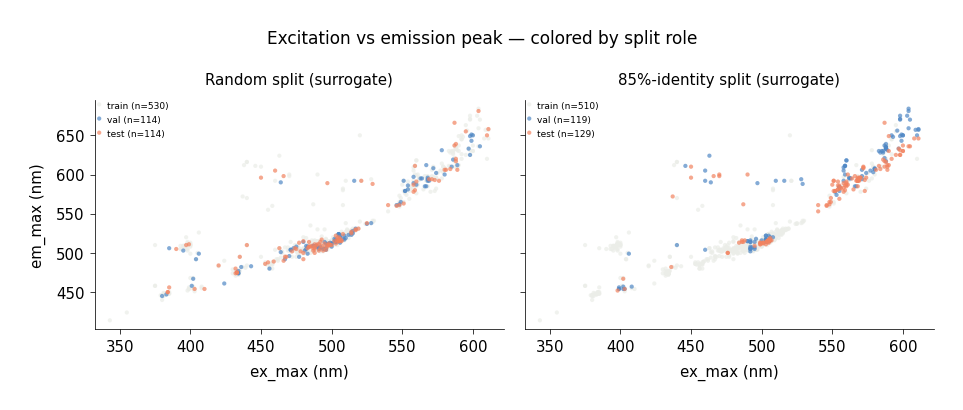

In [7]:
fig,ax=plt.subplots(1,2,figsize=(13,5.2),sharex=True,sharey=True)
palette={"train":apc_c.gray,"val":apc_c.aegean,"test":apc_c.amber}
for col,(title,role) in enumerate([("Random split (surrogate)",RSr),("85%-identity split (surrogate)",Sr)]):
    a=ax[col]
    for s in ("train","val","test"):
        idx=np.where(role==s)[0]
        a.scatter(peaks[idx,0],peaks[idx,1],s=18,alpha=0.7,color=palette[s],label=f"{s} (n={len(idx)})",edgecolors="none")
    a.set_title(title); a.set_xlabel("ex_max (nm)"); a.legend(fontsize=9,loc="upper left")
ax[0].set_ylabel("em_max (nm)")
plt.suptitle("Excitation vs emission peak — colored by split role"); plt.tight_layout(); plt.show()


## Summary

- Stricter **85% identity** yields more, finer clusters than 70%, but the dominant lineage stays
  large, so a random split still leaks most of its test set.
- The 85%-identity split keeps the coordinated dual structure with **0 shared clusters** across
  train/val/test.
- New artifacts: `seqid85_clusters.csv`, `dual_splits_seqid85.csv`.
- Next: `surrogate_oracle_peak_seqid85.ipynb`.
